In [1]:
#устранить несбалансированность датасета, можно путем добавления class_weights
#почему accuracy черт возьми больше 1 ??

In [2]:
!rm -rf train val test

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import numpy as np 
import pandas as pd 
from IPython.display import clear_output
import torch
import torchvision
import torchvision.models as models
import matplotlib.pyplot as plt
import time
import copy

from torchvision import transforms, models
import seaborn as sns
sns.set_style('darkgrid')


import os

np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)

In [5]:
data_root = '/content/drive/MyDrive/computer vision/horse-or-human'
print(os.listdir(data_root))

['validation', 'train']


In [6]:
import shutil 
from tqdm import tqdm

train_dir = 'train'
val_dir = 'validation'

class_names = ['horses', 'humans']

for dir_name in [train_dir, val_dir]:
    for class_name in class_names:
        os.makedirs(os.path.join(dir_name, class_name), exist_ok=True)

for dir_name in [train_dir, val_dir]:
    for class_name in class_names:
        source_dir = os.path.join(data_root, dir_name, class_name)
        for file_name in tqdm(os.listdir(source_dir)):
            dest_dir = os.path.join(dir_name, class_name) 
            shutil.copy(os.path.join(source_dir, file_name), os.path.join(dest_dir, file_name))

100%|██████████| 128/128 [00:00<00:00, 199.21it/s]


In [7]:
len(os.listdir('train/horses')),\
len(os.listdir('train/humans'))

(220, 527)

In [8]:
#датасет несбалансированный, нужно добавить аугментацию

batch_size = 8

train_transforms = transforms.Compose([transforms.Resize((224, 224)),
                                       #transforms.ColorJitter(hue=(-0.5,0.5)),
                                       transforms.RandomHorizontalFlip(),
                                       transforms.RandomVerticalFlip(),
                                       transforms.ToTensor(),
                                       #transforms.Lambda(lambda x: x[np.random.permutation(3), :, :]),
                                       transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])


val_transforms = transforms.Compose([transforms.Resize((224, 224)),
                                     transforms.ToTensor(),
                                     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])



train_dataset = torchvision.datasets.ImageFolder(train_dir, train_transforms)
val_dataset = torchvision.datasets.ImageFolder(val_dir, val_transforms)


train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

dataloaders = {'train': train_dataloader, 'val': val_dataloader}
datasetsizes = {'train': len(train_dataset), 'val': len(val_dataset)}

In [9]:
len(train_dataset), len(train_dataloader)

(747, 94)

In [10]:
747/94

7.946808510638298

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


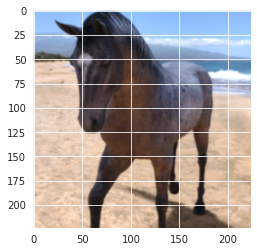

In [11]:
X_batch, y_batch = next(iter(train_dataloader))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
plt.imshow(X_batch[4].permute(1, 2, 0).numpy() * std + mean)

In [12]:
def show_image_classification(dataloader, title=''):
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    X_batch, y_batch = next(iter(dataloader))

    fig, ax = plt.subplots(2, 3, figsize=(12, 9))

    for x_item, y_item, i, j in zip(X_batch, y_batch, [0, 0, 0, 1, 1, 1], [0, 1, 2, 0, 1, 2]):
    
        image = x_item.permute(1, 2, 0).numpy()
        image = std * image + mean
        
        title = class_names[y_item]
        
        ax[i, j].imshow(image.clip(0, 1))
        ax[i, j].set_title(title)

        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

    fig.tight_layout()
    plt.show()

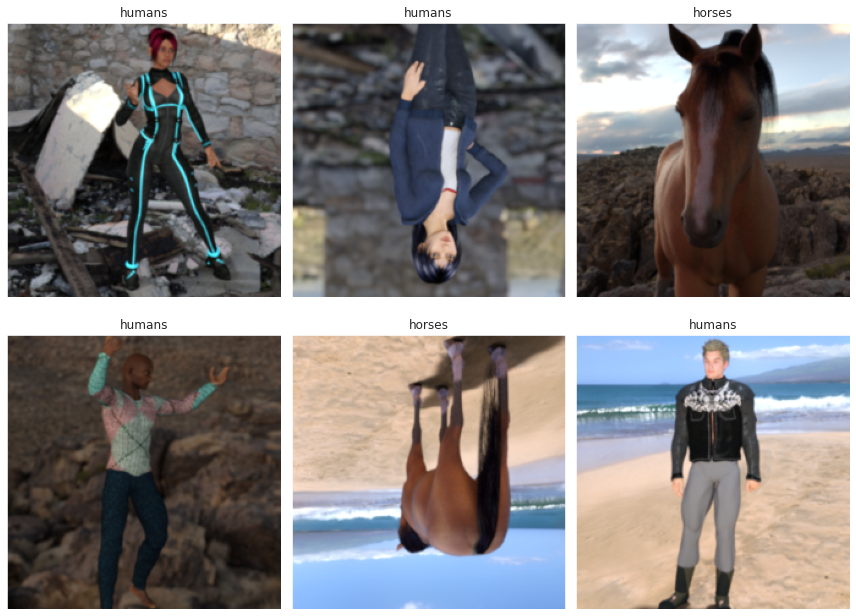

In [13]:
show_image_classification(train_dataloader)

In [14]:
from tqdm.autonotebook import tqdm, trange
import time

def train_model(model, criterion, optimizer, scheduler, num_epochs):
    since = time.time()

    best_model_wts = model.state_dict()
    best_acc = 0.0
    
  
    losses = {'train': [], "val": []}

    pbar = trange(num_epochs, desc="Epoch:")

    for epoch in pbar:

        # каждя эпоха имеет обучающую и тестовую стадии
        for phase in ['train', 'val']:
            if phase == 'train':
                scheduler.step()
                model.train(True)  # установаить модель в режим обучения
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # итерируемся по батчам
            for data in tqdm(dataloaders[phase], leave=False, desc=f"{phase} iter:"):
                # получаем картинки и метки
                inputs, labels = data

                # оборачиваем в переменные
                if torch.cuda.is_available:
                    inputs = inputs.cuda()
                    labels = labels.cuda()
                else:
                    inputs, labels = inputs, labels

                # инициализируем градиенты параметров
                if phase=="train":
                    optimizer.zero_grad()

                # forward pass
                if phase == "eval":
                    with torch.no_grad():
                        outputs = model(inputs)
                else:
                    outputs = model(inputs)
                preds = torch.argmax(outputs, -1)
                loss = criterion(outputs, labels)

                # backward pass + оптимизируем только если это стадия обучения
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

                # статистика
                running_loss += loss.item()
                running_corrects += int(torch.sum(preds == labels.data))

            epoch_loss = running_loss / datasetsizes[phase]
            epoch_acc = running_corrects / datasetsizes[phase]
            
            losses[phase].append(epoch_loss)
            
            pbar.set_description('{} Loss: {:.4f} Acc: {:.4f}'.format(
                                    phase, epoch_loss, epoch_acc
                                ))

            # если достиглось лучшее качество, то запомним веса модели
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # загрузим лучшие веса модели
    model.load_state_dict(best_model_wts)
    return model, losses

In [15]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = torch.nn.Linear(model.fc.in_features, 2)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1.0e-5)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [16]:
model, losses = train_model(model, loss, optimizer, scheduler, num_epochs=15);

Epoch::   0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.7/dist-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  "https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate", UserWarning)


train iter::   0%|          | 0/94 [00:00<?, ?it/s]

val iter::   0%|          | 0/32 [00:00<?, ?it/s]

train iter::   0%|          | 0/94 [00:00<?, ?it/s]

...

train iter::   0%|          | 0/94 [00:00<?, ?it/s]

val iter::   0%|          | 0/32 [00:00<?, ?it/s]

train iter::   0%|          | 0/94 [00:00<?, ?it/s]

val iter::   0%|          | 0/32 [00:00<?, ?it/s]

Training complete in 2m 6s
Best val Acc: 0.886719


In [17]:
def evaluate(model):
    model.eval()
    
    runninig_correct = 0
    for data in dataloaders['val']:
        # получаем картинки и метки
        inputs, labels = data
        
        # переносим на gpu, если возможно
        if torch.cuda.is_available:
            inputs = inputs.cuda()
            labels = labels.cuda()
            
        # forard pass
        output = model(inputs)
        _, predicted = torch.max(output, 1)
        
        runninig_correct += int(torch.sum(predicted == labels))
        
    return runninig_correct / datasetsizes['val']

evaluate(model)

0.875

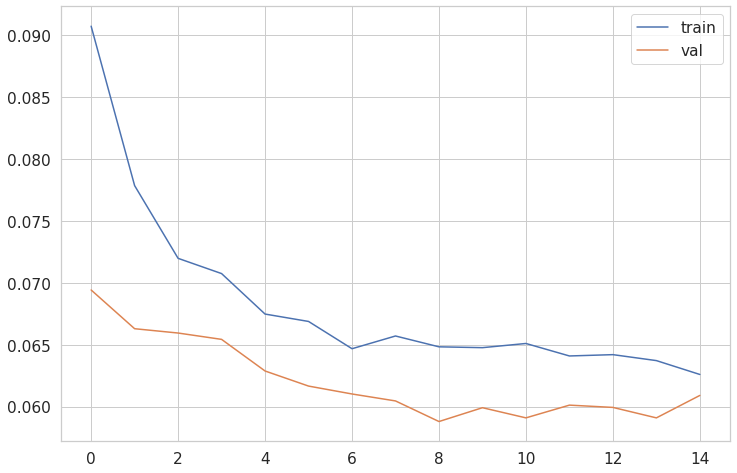

In [20]:
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.4)

# Построим график лосса при обучении и валидации

plt.figure(figsize=(12, 8))
plt.plot(losses['train'], label="train")
plt.plot(losses['val'], label="val")
plt.legend()
plt.show()